<a href="https://colab.research.google.com/github/Shiv-Sai20111018/eos-ai-workshop/blob/main/Session3-Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐼 Session 3 — Data Science with Pandas + Stats
**EOS Sunshine × Spark TBI · AI Workshop 2026 · Week 2 Friday**

Today: load real IPL data, clean it, filter, group, **then** learn the stats foundations (mean / median / mode / outliers / probability), **then** visualise.

Companion to slides at https://orent.vercel.app/session-3.

**Run cells with Shift+Enter ▶**

---

## 🗺️ Flow today
1. **Pandas** — load, peek, filter, clean, group
2. **Stats** — mean / median / mode + outlier impact
3. **Probability** — basics + how it shows up in ML
4. **Visualisation** — Matplotlib + Seaborn (charts of what we measured)
5. **Lab** — IPL Player Analyser challenge

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
print('pandas', pd.__version__)
print('numpy', np.__version__)

pandas 2.2.2
numpy 2.0.2


---
# 🐼 Part 1 — Pandas

## 📥 Step 1 — Load `data.csv` (real IPL stats, intentionally messy)

We have a CSV file with **75 rows × 16 columns** of multi-season IPL batting stats. Some cells are messy on purpose — duplicates, NaN, mixed types — so you can practice cleaning.

In [ ]:
# First — what IS a DataFrame? (matches slide 9)
# A DataFrame is a 2D table with labelled columns. You can build one from a dict:
df = pd.DataFrame({
    'player': ['Kohli', 'Rohit', 'Dhoni'],
    'runs':   [639, 332, 224],
    'avg':    [53.25, 24.62, 20.36]
})
df

,player,runs,avg
0,Kohli,639,53.25
1,Rohit,332,24.62
2,Dhoni,224,20.36


In [ ]:
# Now load REAL data — straight from the workshop website
url = 'https://orent.vercel.app/data.csv'
ipl = pd.read_csv(url)

print('Shape:', ipl.shape)
ipl.tail(10)

Shape: (75, 16)


,player_id,player,team,season,matches,innings,runs,highest_score,avg,strike_rate,fifties,hundreds,fours,sixes,is_captain,role
65,66,J Buttler,RR,2023,8,8,392,95*,49.00,144.64,4,0,33,16,No,Wicketkeeper
66,67,V Kohli,RCB,2023,14,14,639,101*,53.25,139.82,6,2,68,21,Yes,Batsman
67,68,P Cummins,SRH,2024,13,7,147,50*,21.00,164.04,1,0,5,8,Yes,Allrounder
68,69,T Head,SRH,2024,15,15,567,102,40.50,191.55,3,1,64,32,No,Batsman
69,70,Sai Kishore,GT,2024,7,2,12,12*,12.00,109.09,0,0,1,1,No,Allrounder
70,71,B Stoinis,LSG,2024,14,14,498,124*,DNB,147.78,2,1,33,32,No,Allrounder
71,72,J Hazlewood,RCB,2024,11,2,16,11*,16.00,123.08,0,0,2,1,No,Bowler
72,73,B Kumar,SRH,2023,14,2,11,11,NaN,118.18,0,0,1,0,No,Bowler
73,74,Mukesh Kumar,DC,2024,8,1,5,5*,NaN,71.43,0,0,1,0,No,Bowler
74,75,K Yadav,DC,2022,8,2,6,5,3.00,75.00,0,0,1,0,No,Bowler


## 🔍 Step 2 — First Peek (the 30-second ritual)

In [ ]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   player_id      75 non-null     int64  
 1   player         75 non-null     object 
 2   team           75 non-null     object 
 3   season         75 non-null     int64  
 4   matches        75 non-null     int64  
 5   innings        75 non-null     int64  
 6   runs           75 non-null     int64  
 7   highest_score  75 non-null     object 
 8   avg            73 non-null     object 
 9   strike_rate    75 non-null     float64
 10  fifties        75 non-null     int64  
 11  hundreds       75 non-null     int64  
 12  fours          75 non-null     int64  
 13  sixes          75 non-null     int64  
 14  is_captain     75 non-null     object 
 15  role           75 non-null     object 
dtypes: float64(1), int64(9), object(6)
memory usage: 9.5+ KB


In [ ]:
ipl.describe()

,player_id,season,matches,innings,runs,strike_rate,fifties,hundreds,fours,sixes
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000
mean,38.000000,2023.413333,12.880000,11.733333,375.120000,146.765467,2.346667,0.413333,33.306667,17.786667
std,21.794495,0.755043,3.008816,4.048134,204.845556,25.796965,2.069687,0.755043,20.758569,10.917743
min,1.000000,2022.000000,4.000000,1.000000,5.000000,71.430000,0.000000,0.000000,1.000000,0.000000
25%,19.500000,2023.000000,11.500000,9.000000,224.000000,133.300000,1.000000,0.000000,16.000000,9.500000
50%,38.000000,2024.000000,14.000000,13.000000,378.000000,144.640000,2.000000,0.000000,32.000000,16.000000
75%,56.500000,2024.000000,15.000000,14.000000,509.500000,158.100000,4.000000,1.000000,46.000000,25.000000
max,75.000000,2024.000000,17.000000,17.000000,890.000000,220.550000,9.000000,4.000000,85.000000,46.000000


🔮 **Predict the Output #1** — what will `ipl.shape` and `len(ipl)` print?

In [ ]:
print(ipl.shape)
print(len(ipl))
print(len(ipl.columns))

(75, 16)
75
16


## 🎯 Step 3 — Selecting Columns

In [ ]:
# One column → Series
ipl['player'].head()

,player
0,V Kohli
1,V Kohli
2,V Kohli
3,R Sharma
4,R Sharma


In [ ]:
# Multiple columns → DataFrame
ipl[['player', 'team', 'season', 'runs']].head()

,player,team,season,runs
0,V Kohli,RCB,2024,741
1,V Kohli,RCB,2023,639
2,V Kohli,RCB,2022,341
3,R Sharma,MI,2024,417
4,R Sharma,MI,2023,332


## 🔎 Step 4 — Filtering Rows

In [ ]:
# Players who scored more than 500 runs in any season
top_scorers = ipl[ipl['runs'] > 500]
top_scorers[['player', 'team', 'season', 'runs', 'avg']].sort_values('runs', ascending=False)

,player,team,season,runs,avg
30,S Hill,GT,2023,890,59.33
13,J Buttler,RR,2022,863,57.53
0,V Kohli,RCB,2024,741,61.75
52,V Kohli,RCB,2024,741,61.75
7,F du Plessis,RCB,2023,730,56.15
46,D Conway,CSK,2023,672,51.69
1,V Kohli,RCB,2023,639,53.25
66,V Kohli,RCB,2023,639,53.25
20,Y Jaiswal,RR,2023,625,48.07
11,KL Rahul,LSG,2022,616,51.33


In [ ]:
# Multiple conditions — wrap each in parentheses, use & not 'and'!
csk_high = ipl[(ipl['team'] == 'CSK') & (ipl['runs'] > 200)]
csk_high[['player', 'season', 'runs']]

,player,season,runs
24,M Gaikwad,2024,583
25,M Gaikwad,2023,590
37,A Rahane,2024,229
46,D Conway,2023,672
57,S Dube,2024,396


In [ ]:
# Top 10 scorers across all seasons
top10 = ipl.sort_values('runs', ascending=False).head(10)
top10[['player', 'team', 'season', 'runs', 'avg']]

,player,team,season,runs,avg
30,S Hill,GT,2023,890,59.33
13,J Buttler,RR,2022,863,57.53
0,V Kohli,RCB,2024,741,61.75
52,V Kohli,RCB,2024,741,61.75
7,F du Plessis,RCB,2023,730,56.15
46,D Conway,CSK,2023,672,51.69
66,V Kohli,RCB,2023,639,53.25
1,V Kohli,RCB,2023,639,53.25
20,Y Jaiswal,RR,2023,625,48.07
11,KL Rahul,LSG,2022,616,51.33


## 🎯 Step 4b — `iloc` vs `loc` (position vs label)

`iloc` = **i**nteger position (like Python list slicing — end excluded).
`loc` = **l**abel-based (uses the index value — end **included**, the gotcha that trips everyone).

In [ ]:
# iloc — by integer position
print('First row (iloc[0]):')
print(ipl.iloc[0][['player', 'team', 'season', 'runs']])
print()

# Slice — first 3 rows, end excluded (Python-style)
print('First 3 rows (iloc[0:3]) — end EXCLUDED:')
print(ipl.iloc[0:3][['player', 'runs']])
print()

# loc — by index label (currently the integer index, but works on any index)
# Set player as the index to see loc shine
indexed = ipl.set_index('player')
print('Look up by player name (loc):')
print(indexed.loc['V Kohli', ['team', 'season', 'runs']])

First row (iloc[0]):
player    V Kohli
team          RCB
season       2024
runs          741
Name: 0, dtype: object

First 3 rows (iloc[0:3]) — end EXCLUDED:
    player  runs
0  V Kohli   741
1  V Kohli   639
2  V Kohli   341

Look up by player name (loc):
        team  season  runs
player                    
V Kohli  RCB    2024   741
V Kohli  RCB    2023   639
V Kohli  RCB    2022   341
V Kohli  RCB    2024   741
V Kohli  RCB    2023   639


## 🧹 Step 5 — Cleaning (the data is intentionally messy!)

`data.csv` has these planted issues — your job is to find and fix them:
1. **Duplicate rows** (same player+team+season — but with different `player_id`)
2. **Lowercase team name** (`'rcb'` instead of `'RCB'`)
3. **`'DNB'` string in numeric `avg` column** (one row)
4. **Empty `avg` cells** (NaN — bowlers who barely batted)

We clean **after** exploring so you see the raw mess first.

In [ ]:
# 1. How many missing values per column?
ipl.isna().sum()

,0
player_id,0
player,0
team,0
season,0
matches,0
innings,0
runs,0
highest_score,0
avg,2
strike_rate,0


In [ ]:
# 2. Find duplicate rows
print('Exact duplicates:        ', ipl.duplicated().sum())                              # 0 — player_id makes them unique
print('Same player+team+season: ', ipl.duplicated(subset=['player','team','season']).sum())  # 3

# Show them
ipl[ipl.duplicated(subset=['player','team','season'], keep=False)].sort_values(['player', 'season'])

Exact duplicates:         0
Same player+team+season:  3


,player_id,player,team,season,matches,innings,runs,highest_score,avg,strike_rate,fifties,hundreds,fours,sixes,is_captain,role
14,15,T Head,SRH,2024,15,15,567,102,40.50,191.55,3,1,64,32,No,Batsman
68,69,T Head,SRH,2024,15,15,567,102,40.50,191.55,3,1,64,32,No,Batsman
1,2,V Kohli,RCB,2023,14,14,639,101*,53.25,139.82,6,2,68,21,Yes,Batsman
66,67,V Kohli,RCB,2023,14,14,639,101*,53.25,139.82,6,2,68,21,Yes,Batsman
0,1,V Kohli,RCB,2024,15,15,741,113*,61.75,154.69,5,1,62,38,No,Batsman
52,53,V Kohli,RCB,2024,15,15,741,113*,61.75,154.69,5,1,62,38,No,Batsman


In [ ]:
# 3. Fix lowercase team — find non-uppercase team values
ipl['team'].value_counts()    # spot the odd one

,count
team,
RCB,10
MI,10
LSG,8
RR,8
SRH,8
KKR,7
CSK,7
DC,6
GT,6


In [ ]:
print(ipl['avg'].unique())

['61.75' '53.25' '22.73' '32.07' '20.75' '19.14' '33.69' '56.15' '33.43'
 '37.14' '34.25' '51.33' '35.90' '57.53' '40.50' '39.92' '41.58' '35.10'
 '30.84' '33.46' '48.07' '48.27' '32.90' '40.55' '53.00' '36.87' '53.67'
 '17.33' '47.91' '51.71' '59.33' '19.64' '27.75' '17.78' '29.13' '29.36'
 '19.08' '19.00' '42.67' '53.50' '35.25' '32.15' '28.86' '32.60' '20.00'
 '51.69' '28.64' '28.46' '37.50' '39.55' '18.00' '57.14' '30.91' '23.73'
 '37.80' '39.60' '16.57' '22.60' '21.17' '25.67' '38.31' '25.25' '49.00'
 '21.00' '12.00' 'DNB' '16.00' nan '3.00']


In [ ]:
ipl['avg'] = pd.to_numeric(ipl['avg'], errors='coerce')
ipl = ipl.dropna(subset=['avg'])

In [ ]:
ipl_clean = ipl.copy()

ipl_clean = (
    ipl_clean
    .drop_duplicates(subset=['player', 'team', 'season'])
)

ipl_clean['team'] = ipl_clean['team'].str.upper()

ipl_clean['avg'] = pd.to_numeric(ipl_clean['avg'], errors='coerce')

ipl_clean = ipl_clean.dropna(subset=['avg'])

ipl_clean = ipl_clean.reset_index(drop=True)

print('Before cleaning:', ipl.shape)
print('After cleaning: ', ipl_clean.shape)

ipl_clean.head()

Before cleaning: (72, 16)
After cleaning:  (69, 16)


,player_id,player,team,season,matches,innings,runs,highest_score,avg,strike_rate,fifties,hundreds,fours,sixes,is_captain,role
0,1,V Kohli,RCB,2024,15,15,741,113*,61.75,154.69,5,1,62,38,No,Batsman
1,2,V Kohli,RCB,2023,14,14,639,101*,53.25,139.82,6,2,68,21,Yes,Batsman
2,3,V Kohli,RCB,2022,16,16,341,73,22.73,115.98,2,0,30,11,Yes,Batsman
3,4,R Sharma,MI,2024,14,14,417,38,32.07,150.54,4,0,53,17,No,Batsman
4,5,R Sharma,MI,2023,16,16,332,65,20.75,132.27,1,0,33,10,Yes,Batsman


## 🧩 Step 6 — groupby (split-apply-combine)

In [ ]:
# Average runs per team
team_avg = ipl_clean.groupby('team')['runs'].mean().sort_values(ascending=False).round(1)
team_avg

,runs
team,
RR,478.5
RCB,467.9
LSG,437.4
GT,405.7
CSK,390.7
MI,307.0
KKR,294.6
SRH,292.2
PBKS,280.5


In [ ]:
# Multiple stats per team in one call
ipl_clean.groupby('team')['runs'].agg(['mean', 'max', 'count']).round(1)

,mean,max,count
team,,,
CSK,390.7,672,7
DC,279.2,446,5
GT,405.7,890,6
KKR,294.6,435,7
LSG,437.4,616,7
MI,307.0,535,10
PBKS,280.5,437,4
RCB,467.9,741,9
RR,478.5,863,8


🔮 **Predict #2** — what does this print?

In [ ]:
demo = pd.DataFrame({
    'team': ['MI', 'CSK', 'MI', 'CSK', 'MI'],
    'runs': [80, 60, 100, 90, 120]
})
print(demo.groupby('team')['runs'].mean())

team
CSK     75.0
MI     100.0
Name: runs, dtype: float64


---
# 📐 Part 2 — Stats Foundations

Before plotting anything, we measure: **mean**, **median**, **mode**, and how outliers distort them.

In [ ]:
# The 3 averages — one line each
scores = pd.Series([30, 45, 50, 55, 60,45,60])

print(f'Mean:   {scores.mean()}')      # the typical value
print(f'Median: {scores.median()}')    # the middle when sorted
print(f'Mode:   {scores.mode().tolist()}  (no repeats here)')

Mean:   49.285714285714285
Median: 50.0
Mode:   [45, 60]  (no repeats here)


In [ ]:
# Apply to real IPL data
print(f"Mean runs:    {ipl_clean['runs'].mean():.1f}")
print(f"Median runs:  {ipl_clean['runs'].median():.1f}")
print(f"Mode runs:    {ipl_clean['runs'].mode().tolist()[:5]}")

Mean runs:    372.1
Median runs:  370.0
Mode runs:    [202, 362, 401, 435, 438]


## ⚠️ Outlier impact — see the lie

In [ ]:
normal = pd.Series([30, 45, 50, 55, 60])
with_outlier = pd.Series([30, 45, 50, 55, 60, 200])  # one freak century

print('NORMAL DAY')
print(f'  Mean:   {normal.mean():.1f}')
print(f'  Median: {normal.median():.1f}')

print('\nWITH OUTLIER (200 added)')
print(f'  Mean:   {with_outlier.mean():.1f}    ← jumped!')
print(f'  Median: {with_outlier.median():.1f}    ← barely moved')

print('\n💡 Median is robust to outliers. Use it when your data has freaks.')

NORMAL DAY
  Mean:   48.0
  Median: 50.0

WITH OUTLIER (200 added)
  Mean:   73.3    ← jumped!
  Median: 52.5    ← barely moved

💡 Median is robust to outliers. Use it when your data has freaks.


🔮 **Predict #3** — outlier effect on the IPL data

In [ ]:
# What if a 'mystery batsman' scored 1500 runs in one season?
fake_scores = pd.Series(ipl_clean['runs'].tolist() + [1500])

print(f'Original mean:   {ipl_clean["runs"].mean():.1f}')
print(f'Original median: {ipl_clean["runs"].median():.1f}')
print(f'\nWith mystery 1500-scorer:')
print(f'  Mean:   {fake_scores.mean():.1f}    ← which way does this jump?')
print(f'  Median: {fake_scores.median():.1f}    ← which way?')

Original mean:   372.1
Original median: 370.0

With mystery 1500-scorer:
  Mean:   388.2    ← which way does this jump?
  Median: 374.0    ← which way?


💡 **Quick rule:** if `mean` and `median` differ a lot, your data is **skewed** → outliers exist on the side mean is pulled toward.
- `mean > median` → **right-skewed** (outliers on the high side)
- `mean < median` → **left-skewed** (outliers on the low side)
- `mean ≈ median` → **symmetric / normal** (no outliers)

---
# 🎲 Part 3 — Probability Basics

`P(event) = (favourable outcomes) / (total outcomes)` — a number from 0 to 1.

In [ ]:
# Simulate 1000 coin flips
np.random.seed(42)
flips = np.random.choice(['H', 'T'], size=1000)
p_heads = (flips == 'H').mean()
print(f'P(heads) over 1000 flips = {p_heads:.3f}')
print('Expected ~0.5 — close enough!')

P(heads) over 1000 flips = 0.490
Expected ~0.5 — close enough!


In [ ]:
# Probability from real data — one-liner using .mean() on True/False
p_50 = (ipl_clean['fifties'] >= 1).mean()
print(f'P(player scored at least one 50+) = {p_50:.2%}')

p_100 = (ipl_clean['hundreds'] >= 1).mean()
print(f'P(player scored a 100+) = {p_100:.2%}')

p_high_avg = (ipl_clean['avg'] > 35).mean()
print(f'P(player has avg > 35) = {p_high_avg:.2%}')

p_captain = (ipl_clean['is_captain'] == 'Yes').mean()
print(f'P(player is captain in their season) = {p_captain:.2%}')

P(player scored at least one 50+) = 76.81%
P(player scored a 100+) = 27.54%
P(player has avg > 35) = 46.38%
P(player is captain in their season) = 30.43%


💡 In Pandas, `.mean()` on a True/False Series gives you the probability directly!

**Why probability matters in ML:** every classification model outputs probabilities (e.g. cat=87%, dog=9%, fox=3%). The label comes from `np.argmax` picking the highest — same method you learned in Session 2.

---
# 📊 Part 4 — Visualisation

Now we plot what we measured.

## Matplotlib — bars, scatter

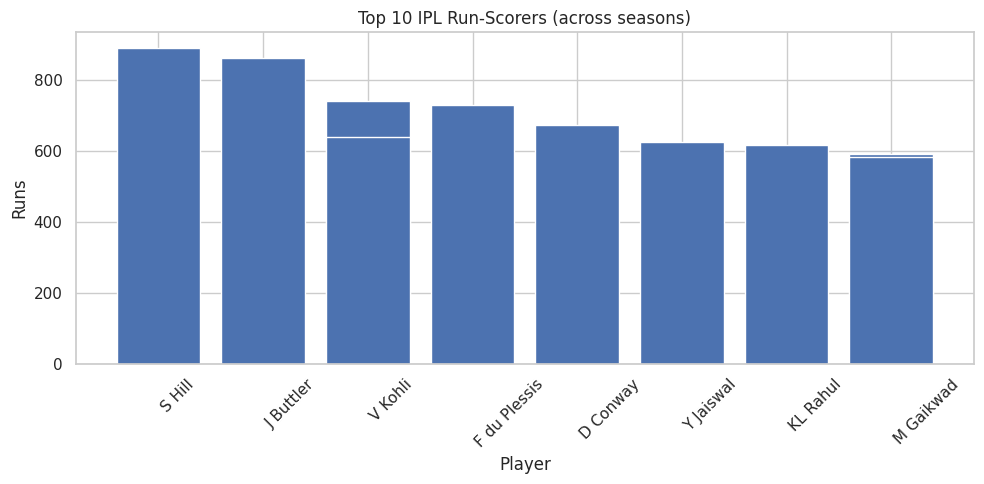

In [ ]:
# Bar chart — top 10 scorers
top10 = ipl_clean.sort_values('runs', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10['player'], top10['runs'])
plt.title('Top 10 IPL Run-Scorers (across seasons)')
plt.xlabel('Player')
plt.ylabel('Runs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

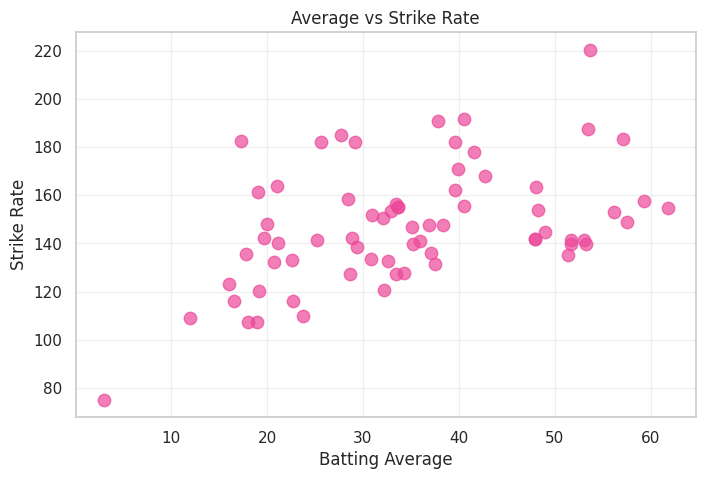

In [ ]:
# Scatter — does avg correlate with strike rate?
plt.figure(figsize=(8, 5))
plt.scatter(ipl_clean['avg'], ipl_clean['strike_rate'], color='#ec4899', s=80, alpha=0.7)
plt.xlabel('Batting Average')
plt.ylabel('Strike Rate')
plt.title('Average vs Strike Rate')
plt.grid(True, alpha=0.3)
plt.show()

## Histograms — Why &amp; how

**Why histograms?**
- 🎯 **Spot the shape** — symmetric, lopsided, or split into clusters?
- 🚨 **Find outliers** — lonely tall bars far from the rest are suspects
- 🧠 **Diagnose before training** — many ML models assume normal data; skew breaks them

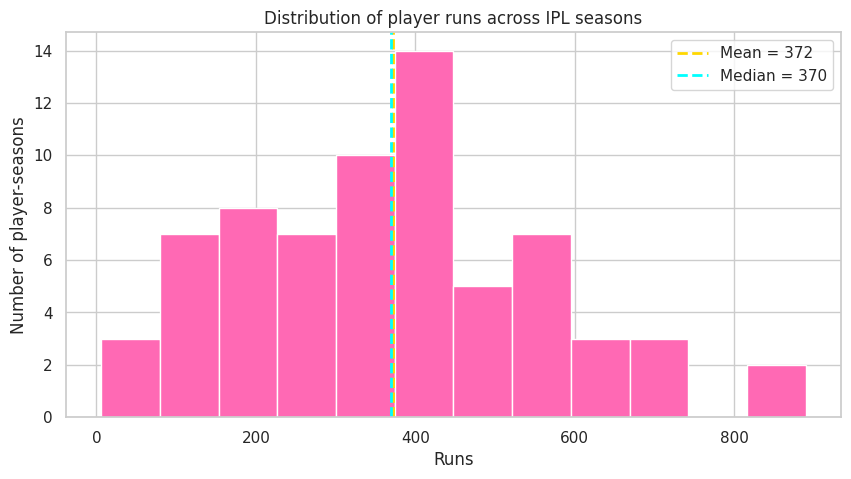

In [ ]:
# Distribution of player runs — what shape?
plt.figure(figsize=(10, 5))
plt.hist(ipl_clean['runs'], bins=12, color='hotpink', edgecolor='white')
plt.title('Distribution of player runs across IPL seasons')
plt.xlabel('Runs')
plt.ylabel('Number of player-seasons')
plt.axvline(ipl_clean['runs'].mean(), color='gold', linestyle='--', linewidth=2, label=f'Mean = {ipl_clean["runs"].mean():.0f}')
plt.axvline(ipl_clean['runs'].median(), color='cyan', linestyle='--', linewidth=2, label=f'Median = {ipl_clean["runs"].median():.0f}')
plt.legend()
plt.show()

## Distribution shapes — right-skewed, left-skewed, normal

Let's generate three datasets to see how each shape looks and where outliers live.

/tmp/ipykernel_7249/3521144716.py:27: UserWarning: Glyph 128276 (\N{BELL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7249/3521144716.py:27: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7249/3521144716.py:27: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128276 (\N{BELL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.

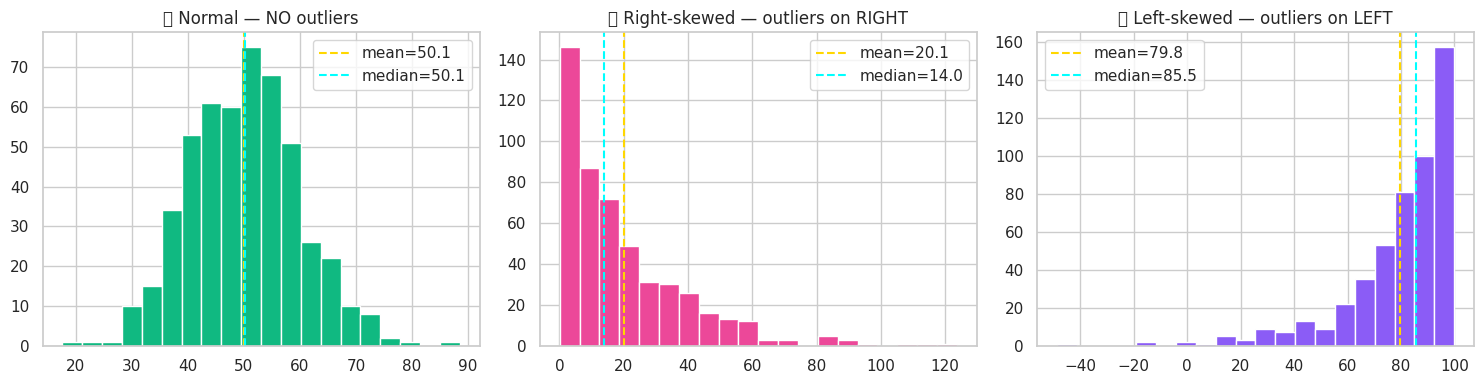


Notice: in skewed plots, mean (gold) and median (cyan) DIFFER.
In the normal plot, they overlap (data is symmetric, no outlier pull).


In [ ]:
np.random.seed(42)

normal = np.random.normal(loc=50, scale=10, size=500)              # ~symmetric bell
right_skew = np.random.exponential(scale=20, size=500)             # tail on the right
left_skew = 100 - np.random.exponential(scale=20, size=500)        # tail on the left

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(normal, bins=20, color='#10b981', edgecolor='white')
axes[0].set_title('🔔 Normal — NO outliers')
axes[0].axvline(normal.mean(), color='gold', linestyle='--', label=f'mean={normal.mean():.1f}')
axes[0].axvline(np.median(normal), color='cyan', linestyle='--', label=f'median={np.median(normal):.1f}')
axes[0].legend()

axes[1].hist(right_skew, bins=20, color='#ec4899', edgecolor='white')
axes[1].set_title('📉 Right-skewed — outliers on RIGHT')
axes[1].axvline(right_skew.mean(), color='gold', linestyle='--', label=f'mean={right_skew.mean():.1f}')
axes[1].axvline(np.median(right_skew), color='cyan', linestyle='--', label=f'median={np.median(right_skew):.1f}')
axes[1].legend()

axes[2].hist(left_skew, bins=20, color='#8b5cf6', edgecolor='white')
axes[2].set_title('📈 Left-skewed — outliers on LEFT')
axes[2].axvline(left_skew.mean(), color='gold', linestyle='--', label=f'mean={left_skew.mean():.1f}')
axes[2].axvline(np.median(left_skew), color='cyan', linestyle='--', label=f'median={np.median(left_skew):.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print('\nNotice: in skewed plots, mean (gold) and median (cyan) DIFFER.')
print('In the normal plot, they overlap (data is symmetric, no outlier pull).')

## Seaborn — boxplots show outliers automatically

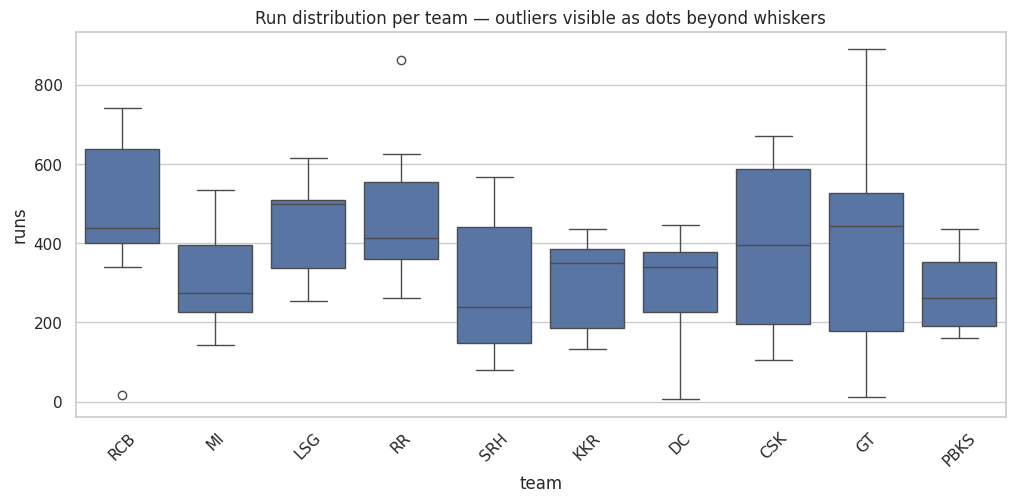

In [ ]:
# Boxplot — runs per team. Dots beyond whiskers = outliers!
plt.figure(figsize=(12, 5))
sns.boxplot(data=ipl_clean, x='team', y='runs')
plt.title('Run distribution per team — outliers visible as dots beyond whiskers')
plt.xticks(rotation=45)
plt.show()

## Heatmap — correlation matrix

Which numeric columns move together? Critical to know **before** ML.

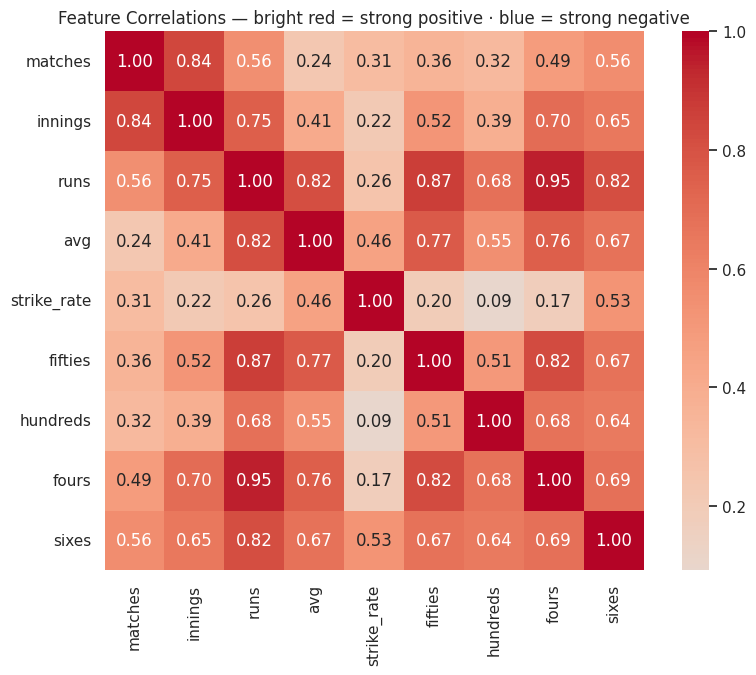

In [ ]:
numeric_cols = ['matches', 'innings', 'runs', 'avg', 'strike_rate', 'fifties', 'hundreds', 'fours', 'sixes']
corr = ipl_clean[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Feature Correlations — bright red = strong positive · blue = strong negative')
plt.show()

## Correlation in scatter form — positive · negative · none

/tmp/ipykernel_7249/2574122956.py:27: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7249/2574122956.py:27: UserWarning: Glyph 128256 (\N{TWISTED RIGHTWARDS ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7249/2574122956.py:27: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128256 (\N{TWISTED RIGHTWARDS ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missi

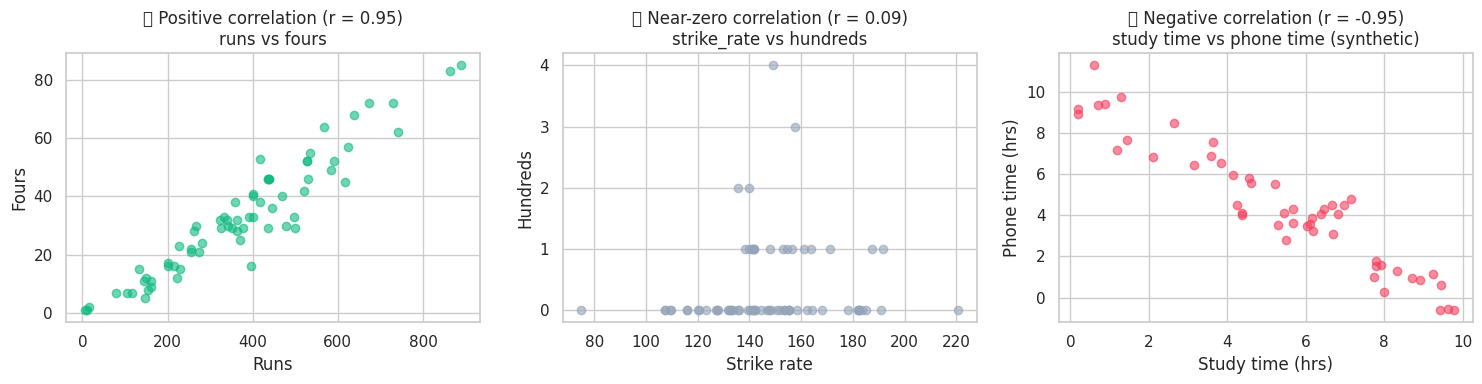


🚨 But remember: correlation ≠ causation!
Ice cream sales and shark attacks rise together — both caused by warm weather, not each other.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Positive — runs vs fours (should rise together)
axes[0].scatter(ipl_clean['runs'], ipl_clean['fours'], color='#10b981', alpha=0.6)
r1 = ipl_clean['runs'].corr(ipl_clean['fours'])
axes[0].set_title(f'📈 Positive correlation (r = {r1:.2f})\nruns vs fours')
axes[0].set_xlabel('Runs')
axes[0].set_ylabel('Fours')

# Near-zero — strike_rate vs hundreds (no relationship in our data)
axes[1].scatter(ipl_clean['strike_rate'], ipl_clean['hundreds'], color='#94a3b8', alpha=0.6)
r2 = ipl_clean['strike_rate'].corr(ipl_clean['hundreds'])
axes[1].set_title(f'🔀 Near-zero correlation (r = {r2:.2f})\nstrike_rate vs hundreds')
axes[1].set_xlabel('Strike rate')
axes[1].set_ylabel('Hundreds')

# Negative — IPL data has no strong negatives, so we synthesise one for illustration
np.random.seed(0)
x_neg = np.random.uniform(0, 10, 50)
y_neg = 10 - x_neg + np.random.normal(0, 1, 50)
axes[2].scatter(x_neg, y_neg, color='#f43f5e', alpha=0.6)
r3 = pd.Series(x_neg).corr(pd.Series(y_neg))
axes[2].set_title(f'📉 Negative correlation (r = {r3:.2f})\nstudy time vs phone time (synthetic)')
axes[2].set_xlabel('Study time (hrs)')
axes[2].set_ylabel('Phone time (hrs)')

plt.tight_layout()
plt.show()

print('\n🚨 But remember: correlation ≠ causation!')
print('Ice cream sales and shark attacks rise together — both caused by warm weather, not each other.')

---
# 🏏 Hands-On Lab — IPL Player Analyser

**30-min mission.** Use everything you've learned.

Find the top 3 batsmen by **mean** runs across seasons. Then check if any of them are <b>fooling you</b> with one outlier — would the **median** rank them differently?

In [ ]:
# 1. Group by player — both mean and median runs across seasons
player_stats = ipl_clean.groupby('player')['runs'].agg(['mean', 'median', 'count'])

# 2. Top 3 by mean (only players with at least 2 seasons of data, for fairness)
qualified = player_stats[player_stats['count'] >= 2]
top3 = qualified.sort_values('mean', ascending=False).head(3)
print('🏆 Top 3 by MEAN runs across seasons:')
print(top3)
print()

# 3. Mean-Median gap (large gap = outlier-skewed)
top3 = top3.copy()
top3['gap'] = top3['mean'] - top3['median']
print('📊 Gap between mean and median (large gap = one season skews the average):')
print(top3.sort_values('gap', ascending=False))

🏆 Top 3 by MEAN runs across seasons:
                    mean  median  count
player                                 
M Gaikwad     586.500000   586.5      2
V Kohli       573.666667   639.0      3
F du Plessis  545.333333   468.0      3

📊 Gap between mean and median (large gap = one season skews the average):
                    mean  median  count        gap
player                                            
F du Plessis  545.333333   468.0      3  77.333333
M Gaikwad     586.500000   586.5      2   0.000000
V Kohli       573.666667   639.0      3 -65.333333


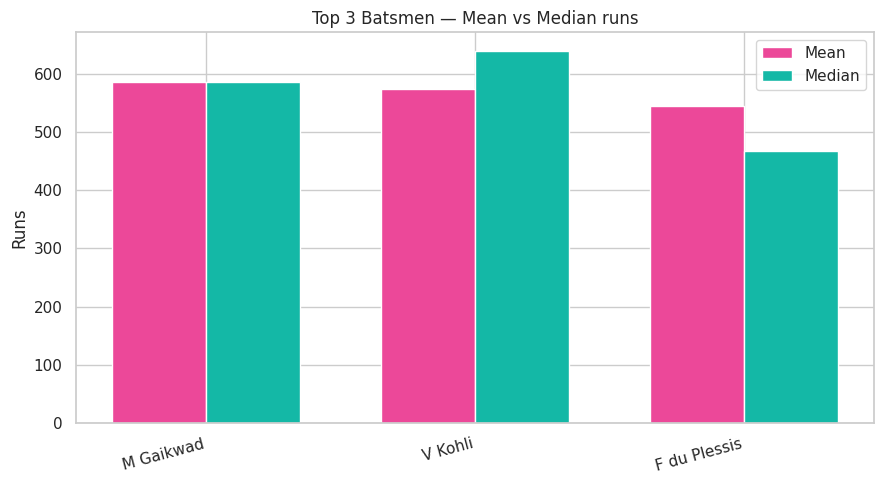

In [ ]:
# 4. Plot top 3 — bar chart with both mean & median
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(top3))
width = 0.35
ax.bar(x - width/2, top3['mean'], width, label='Mean', color='#ec4899')
ax.bar(x + width/2, top3['median'], width, label='Median', color='#14b8a6')
ax.set_xticks(x)
ax.set_xticklabels(top3.index, rotation=15, ha='right')
ax.set_ylabel('Runs')
ax.set_title('Top 3 Batsmen — Mean vs Median runs')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 5. Bonus — probability the top batsman scored a 50+ in any random match
top_player = top3.index[0]
rows = ipl_clean[ipl_clean['player'] == top_player]
total_50s = rows['fifties'].sum() + rows['hundreds'].sum()  # 50s already include innings ≥50
total_innings = rows['innings'].sum()
p_50 = total_50s / total_innings
print(f'P({top_player} scores 50+ in an innings) ≈ {p_50:.2%}')
print(f'  ({int(total_50s)} fifties+ in {int(total_innings)} innings)')

P(M Gaikwad scores 50+ in an innings) ≈ 30.00%
  (9 fifties+ in 30 innings)


## 🌟 Stretch challenges

1. **Histogram** of `strike_rate` for all players — is it normal, right-skewed, or left-skewed?
2. **Boxplot** of runs grouped by `role` — which role has the most outliers?
3. **Heatmap** of correlations for just CSK players — different from overall?
4. **Probability** — `P(player has avg > 40 GIVEN they're a Wicketkeeper)`?
5. **Add an outlier**: what if a fake player scored 2000 runs? Does the top-3 ranking change?

In [ ]:
# Your stretch work here...

---
## 🎉 Done!

You now know:

- ✅ **Pandas** — load `data.csv`, clean (duplicates, NaN, type errors), filter, group, aggregate
- ✅ **Stats** — mean / median / mode + how outliers distort the mean (median is robust)
- ✅ **Distribution shapes** — normal · right-skewed · left-skewed, and where outliers hide in each
- ✅ **Probability** — `P(event) = favourable / total`, and `.mean()` on a boolean Series
- ✅ **Visualisation** — bar / line / scatter / histogram / boxplot / heatmap
- ✅ How to read a **correlation matrix** (and why correlation ≠ causation)

## 📤 Submit by Thursday 11:59 PM

1. Save this notebook to `eos-ai-workshop/week-02/`
2. Add your top-3 chart screenshot
3. Drop your repo URL in Google Chat — bonus points if you write a 1-line insight: *'My top batsman is X, but their median tells a different story…'*

## 📅 Next: Saturday — ML with scikit-learn

**Same `data.csv`** — we'll use it to train models. KNN, Decision Trees, Logistic Regression. Predict whether a player will score 50+ from their other stats.

**Great work today! 🎉**